-> use the same data as the data management, it should not download anything again

In [1]:
from madas import MaterialsDatabase

query = {
    "results.material.structural_type:any": [
      "bulk"
    ],
    "results.method.method_name:any": [
      "DFT"
    ],
    "datasets.dataset_name:any": [
      "Hybrid organic inorganic perovskite"
    ],
    "results.properties.available_properties:all": [
      "dos_electronic"
    ],
    "results.material.elements:all": [
      "O"
    ]
  }

db = MaterialsDatabase(filename='hybrid_organic_inorganic_perovskites.db')

db.fill_database(query)

2026-03-31 10:14:37,859 - hybrid_organic_inorganic_perovskites_log - INFO - Query has already been performed.


In [2]:
db[0].data['archive']['results']['properties']['electronic']

{'dos_electronic': {'energies': '/run/0/calculation/0/dos_electronic/0/energies',
  'total': ['/run/0/calculation/0/dos_electronic/0/total/0'],
  'spin_polarized': False,
  'energy_fermi': 1.6180836364277064e-19,
  'band_gap': [{'index': 0,
    'energy_highest_occupied': 1.5734976722514e-19,
    'energy_lowest_unoccupied': 1.5734976722514e-19}]}}

In [18]:
from scipy.constants import electron_volt
from madas.utils import resolve_nested_dict
import numpy as np

from madas import Material

def get_dos_values(material: Material) -> list:
    """
    Get total DOS per unit cell and eV from NOMAD archive dictionary.
    """
    spin_channels = []
    dos_paths = resolve_nested_dict(material.data, "archive/results/properties/electronic/dos_electronic/total")
    for path_ in dos_paths:
        norm_factor = resolve_nested_dict(material.data, f'archive{path_}/normalization_factor', fail_on_key_error=True)
        dos = np.array(resolve_nested_dict(material.data, f'archive{path_}/value', fail_on_key_error=True)) * norm_factor * electron_volt
        spin_channels.append(dos)
    return sum(spin_channels).tolist()
    
def get_dos_energies(material: Material) -> list:
    """
    Get DOS energies in eV from a NOMAD archive dictionary, normalized such that E=0 is at the VBM.
    """
    dos_results = resolve_nested_dict(material.data, "archive/results/properties/electronic/dos_electronic")
    if isinstance(dos_results, list):
        dos_results=dos_results[0]
    energies_path = resolve_nested_dict(dos_results, "energies")
    energies_path = energies_path[1:] if energies_path.startswith("#/") else energies_path
    efermi_0 = resolve_nested_dict(dos_results, "band_gap/0/energy_highest_occupied")
    try:
        efermi_1 = resolve_nested_dict(dos_results, "band_gap/1/energy_highest_occupied")
        efermi = max([efermi_0, efermi_1])
    except IndexError:
        efermi = efermi_0
    dos_energies = (np.array(resolve_nested_dict(material.data, f"archive{energies_path}")) - efermi) / electron_volt
    return dos_energies.tolist()


## Using built-in fingerprints

### Defining and tuning DOS fingerprints

In [19]:
from madas.utils import tqdm

mids_properties = []
for entry in tqdm(db):
    mids_properties.append([entry.mid, get_dos_values(entry), get_dos_energies(entry)])
# --> write to data instead
#db.update_entries(mids, properties_dicts)

  0%|          | 0/400 [00:00<?, ?it/s]

In [20]:
from madas.fingerprints import DOSFingerprint

In [83]:
grid = DOSFingerprint.get_default_grid()

In [85]:
grid.n_pix = 1024

In [86]:
fps = []
for mid, dos_values, dos_energies in tqdm(mids_properties):
    fp = DOSFingerprint(grid=grid).calculate(dos_energies, dos_values)
    fp.set_mid(mid)
    fps.append(fp)

  0%|          | 0/400 [00:00<?, ?it/s]

In [87]:
import matplotlib.pyplot as plt

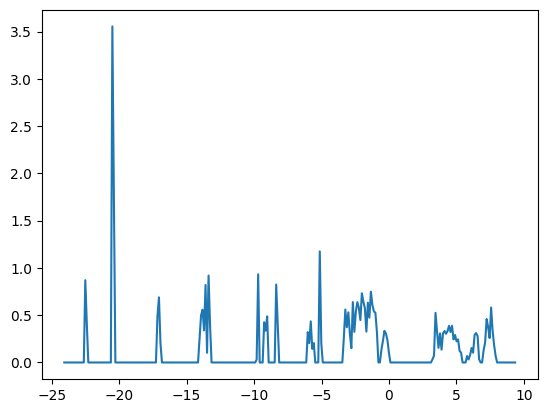

In [88]:
plt.plot(mids_properties[0][2], mids_properties[0][1])

In [90]:
fps[1].get_similarities(fps)

[0.5784828745534776,
 1.0,
 0.2889437689969605,
 0.6580299307572035,
 0.46058178752107926,
 0.5289598108747045,
 0.1989606533036377,
 0.437820118828109,
 0.42826963702707893,
 0.5498539841468503,
 0.4618595825426945,
 0.35611297649614854,
 0.39636948529411764,
 0.4754,
 0.5054401582591493,
 0.34855714610315836,
 0.36950383219039934,
 0.5511613308223478,
 0.4943820224719101,
 0.553633930409718,
 0.5292542233209724,
 0.48132080019281753,
 0.3336606923643506,
 0.4908996359854394,
 0.7029121653358384,
 0.35345581802274717,
 0.3568019093078759,
 0.4490876986462625,
 0.5937215650591446,
 0.41518034086405076,
 0.4207702625023951,
 0.3867595818815331,
 0.522920892494929,
 0.608359133126935,
 0.3894620486366986,
 0.28892668178382463,
 0.5665813060179258,
 0.46849852796859665,
 0.5455105814670228,
 0.5272950316908608,
 0.42547274749721914,
 0.5836802664446294,
 0.36888787809870366,
 0.1827165685449958,
 0.46626000762485703,
 0.3572846367606193,
 0.31671220400728595,
 0.3322975335016508,
 0.32490

## Creating custom fingerprints

In [206]:
from madas import Fingerprint

In [208]:
example_material.atoms.get_atomic_numbers()

array([35, 35, 35,  1,  1,  1,  1, 50,  7,  8])

In [210]:
atoms_numbers_dict = {}
for number in example_material.atoms.get_atomic_numbers():
    try:
        atoms_numbers_dict[number] += 1
    except KeyError:
        atoms_numbers_dict[number] = 1
atoms_numbers_dict_2 = {}
for number in example_material_2.atoms.get_atomic_numbers():
    try:
        atoms_numbers_dict_2[number] += 1
    except KeyError:
        atoms_numbers_dict_2[number] = 1

In [211]:
atoms_numbers_dict_2

{np.int64(53): 3,
 np.int64(1): 4,
 np.int64(82): 1,
 np.int64(7): 1,
 np.int64(8): 1}

In [212]:
atoms_numbers_dict

{np.int64(35): 3,
 np.int64(1): 4,
 np.int64(50): 1,
 np.int64(7): 1,
 np.int64(8): 1}

In [213]:
overlap = 0
for number in atoms_numbers_dict.keys():
    try:
        overlap += min(atoms_numbers_dict[number], atoms_numbers_dict_2[number])
    except KeyError:
        pass

In [214]:
overlap

6

In [215]:
sum(atoms_numbers_dict.values())

10

In [216]:
similarity = overlap / (sum(atoms_numbers_dict.values()) + sum(atoms_numbers_dict_2.values()) - overlap)

In [217]:
similarity

0.42857142857142855

In [221]:
from ase import Atoms 

def AtomicNumbers_similarity(fingerprint1, fingerprint2):
    number_dict1 = fingerprint1.data['atomic_numbers_dict']
    number_dict2 = fingerprint2.data['atomic_numbers_dict']
    overlap = 0
    for number in number_dict1.keys():
        try:
            overlap += min(number_dict1[number], number_dict2[number])
        except KeyError:
            pass
    similarity = overlap / (sum(number_dict1.values()) + sum(number_dict2.values()) - overlap)
    return similarity

class AtomicNumbersFingerprint(Fingerprint):

   # This declaration can be skipped.
   # However, it is advised to explicitly write the `__init__` function.
    def __init__(self,
               name = "AtomicNumbers",
               similarity_function=AtomicNumbers_similarity,
               pass_on_exceptions=True) -> None:
        super().__init__(name=name, 
                         similarity_function=similarity_function, 
                         pass_on_exceptions=pass_on_exceptions)

    def calculate(self, atoms: Atoms):
        # get the maximal atomic number from ASE Atoms object
        atoms_numbers_dict = {}
        for number in atoms.get_atomic_numbers().tolist():
            try:
                atoms_numbers_dict[number] += 1
            except KeyError:
                atoms_numbers_dict[number] = 1
            # REQUIRED: set the fingerprint data
        self.set_data("atomic_numbers_dict", atoms_numbers_dict)
        # REQUIRED: return self
        return self
    
    def from_material(self, material: Material):
        # REQUIRED: set the material identifier for this fingerprint
        self.set_mid(material)
        # use obtain properties from the material object
        atoms = material.atoms
        # calculate the fingerprint
        self.calculate(atoms)
        # REQUIRED: return self
        return self

In [128]:
fps = db.get_fingerprints(AtomicNumbersFingerprint, similarity_function=AtomicNumbers_similarity)

2026-03-31 15:23:21,349 - hybrid_organic_inorganic_perovskites_log - INFO - Generating "<class '__main__.AtomicNumbersFingerprint'>" fingerprints.


  0%|          | 0/400 [00:00<?, ?it/s]

## Saving fingerprints to the database

In [219]:
#db.add_fingerprint('DOS', fingerprint_kwargs={'grid':grid})

In [222]:
db.add_fingerprint(AtomicNumbersFingerprint)

2026-03-31 16:39:12,870 - hybrid_organic_inorganic_perovskites_log - INFO - Generating AtomicNumbersFingerprint fingerprints...
2026-03-31 16:39:12,873 - hybrid_organic_inorganic_perovskites_log - INFO - Generating "<class '__main__.AtomicNumbersFingerprint'>" fingerprints.


  0%|          | 0/400 [00:00<?, ?it/s]

2026-03-31 16:39:16,178 - hybrid_organic_inorganic_perovskites_log - INFO - Writing AtomicNumbersFingerprint fingerprints to database...
2026-03-31 16:39:23,515 - hybrid_organic_inorganic_perovskites_log - INFO - Finished generation of AtomicNumbersFingerprint fingerprints.


In [224]:
db[0].properties['AtomicNumbersFingerprint']

'{"mid": "r0nrMz72q7RGOSq9TzFu8ydzOiS7", "name": "AtomicNumbersFingerprint", "fp_type": "AtomicNumbersFingerprint", "data": "{\\"atomic_numbers_dict\\": {\\"17\\": 3, \\"1\\": 4, \\"50\\": 1, \\"7\\": 1, \\"8\\": 1}}", "pass_on_exceptions": false}'